# EVAC Part 1

In [1]:
import numpy
import matplotlib.pyplot as plt
import random
from deap import base, creator, tools, algorithms
from scipy.stats import mannwhitneyu

# DATA

In [2]:
# Food,Cost,Protein,Fat,Carbohydrate,Calories
data = [
    ["Bread",2.0,4.0,1.0,15.0,90],

    ["Milk",3.5,8.0,5.0,11.7,120],

    ["Cheese",8.0,7.0,9.0,0.4,106],

    ["Potato",1.5,1.3,0.1,22.6,97],

    ["Fish",11.0,8.0,7.0,0.0,130],

    ["Yoghurt",1.0,9.2,1.0,17.0,180],
]

# Constraints
CALORIES_MIN = 300
PROTEIN_MAX = 10
CARBS_MIN = 10
FAT_MIN = 8
FISH_MIN = 0.5
MILK_MAX = 1.0

# EVOLUTIONARY ALGORITHM

In [3]:
# GA Functions
def evalDiet(individual):
    '''
    Evaluate the diet by calculating total cost and checking constraints.
    * param individual: A list of amounts for each food item.
    * return: A tuple containing the total cost (or a high cost if constraints are violated).
    '''
    total_cost = 0
    total_protein = 0
    total_fat = 0
    total_carbs = 0
    total_calories = 0
    penalty = 100

    # Check for negative amounts and return high cost if found
    total_cost += sum(abs(amt) for amt in individual if amt < 0) * penalty

    # Calculate total cost and nutrients
    for i in range(len(data)):
        amount = max(0, individual[i]) # Ensure no negative amounts
        total_cost += amount * data[i][1]
        total_protein += amount * data[i][2]
        total_fat += amount * data[i][3]
        total_carbs += amount * data[i][4]
        total_calories += amount * data[i][5]

    # Check constraints and add penalties
    total_cost += penalty * (CALORIES_MIN - total_calories) if total_calories < CALORIES_MIN else 0
    total_cost += penalty * (total_protein - PROTEIN_MAX) if total_protein > PROTEIN_MAX else 0
    total_cost += penalty * (CARBS_MIN - total_carbs) if total_carbs < CARBS_MIN else 0
    total_cost += penalty * (FAT_MIN - total_fat) if total_fat < FAT_MIN else 0
    total_cost += penalty * (FISH_MIN - individual[4]) if individual[4] < FISH_MIN else 0
    total_cost += penalty * (individual[1] - MILK_MAX) if individual[1] > MILK_MAX else 0

    return total_cost,

In [4]:
#  Create fitness and individual
creator.create("Cost", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.Cost)

# Create toolbox and register functions
toolbox = base.Toolbox()
toolbox.register("food_amount", random.uniform, 0, 4) # maximum of 4 servings per food item as 4 of any item would exceed calorie constraints
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.food_amount, n=len(data))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evalDiet)
toolbox.register("select", tools.selTournament, tournsize=5)
toolbox.register("mate", tools.cxBlend, alpha=1.0)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.1)

# Tools setup for statistics and hall of fame
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
logbook = tools.Logbook()
hof = tools.HallOfFame(1)
stats.register("avg", numpy.mean)
stats.register("std", numpy.std)
stats.register("min", numpy.min)
stats.register("max", numpy.max)
logbook.header = "gen", "avg", "evals", "std", "min", "max"

In [5]:
# Genetic algorithm parameters
NGEN = 200
POP_SIZE = 1000
CXPB = 0.5
MUTPB = 0.2
MU = 500
LAMBDA = 500

# Initial population log them as gen 0
pop = toolbox.population(POP_SIZE)
pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, MU, LAMBDA, CXPB, MUTPB, NGEN, stats, hof)
# pop, logbook = algorithms.eaMuCommaLambda(pop, toolbox, MU, LAMBDA, CXPB, MUTPB, NGEN, stats, hof)
# pop, logbook = algorithms.eaSimple(pop, toolbox, CXPB, MUTPB, NGEN, stats, hof)

gen	nevals	avg    	std   	min    	max    
0  	1000  	6633.76	2019.1	772.358	12831.7
1  	365   	4216.71	1350.78	772.358	8140.49
2  	358   	2634.58	972.559	693.154	4885.74
3  	354   	1505.82	618.052	347.566	3955.72
4  	349   	879.149	280.178	347.566	2124.54
5  	336   	663.18 	136.642	162.053	994.582
6  	351   	495.986	140.206	140.333	772.358
7  	335   	345.561	108.888	140.333	693.154
8  	346   	240.901	80.3135	140.333	453.328
9  	358   	170.87 	39.6195	109.557	347.566
10 	350   	142.861	14.3901	74.9309	243.277
11 	349   	130.622	16.2142	74.9309	140.333
12 	348   	113.015	21.0621	63.0958	140.333
13 	333   	88.7347	15.668 	53.1181	137.743
14 	358   	74.0534	8.06214	53.1181	111.388
15 	340   	67.3505	6.3833 	53.1181	79.7532
16 	341   	61.6039	4.70801	49.1325	74.9309
17 	343   	57.1113	4.29239	49.1325	63.1868
18 	341   	53.4725	1.96859	49.1325	63.0958
19 	357   	52.545 	1.16413	49.1325	53.1181
20 	351   	51.1159	1.67776	47.3774	53.1181
21 	330   	49.4343	1.01215	47.3774	53.7254
22 	358   	48

# RESULTS

In [6]:
# Get the best solution and output everything they chose, nutritional content and what cost they expended
best_ind = hof[0]
print("The best individual orders: Bread=%.2f, Milk=%.2f, Cheese=%.2f, Potato=%.2f, Fish=%.2f, Yoghurt=%.2f" % (
    best_ind[0], 
    best_ind[1], 
    best_ind[2], 
    best_ind[3], 
    best_ind[4], 
    best_ind[5]
))  
print("Nutritional content: Protein=%.2f, Fat=%.2f, Carbs=%.2f, Calories=%.2f" % (
    sum(max(0, best_ind[i]) * data[i][2] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][3] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][4] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][5] for i in range(len(data)))
))
print("With cost %s" % (best_ind.fitness.values))

The best individual orders: Bread=0.02, Milk=0.03, Cheese=0.46, Potato=1.86, Fish=0.50, Yoghurt=0.00
Nutritional content: Protein=9.97, Fat=8.00, Carbs=42.91, Calories=300.00
With cost 12.147973876821275


(10.0, 30.0)

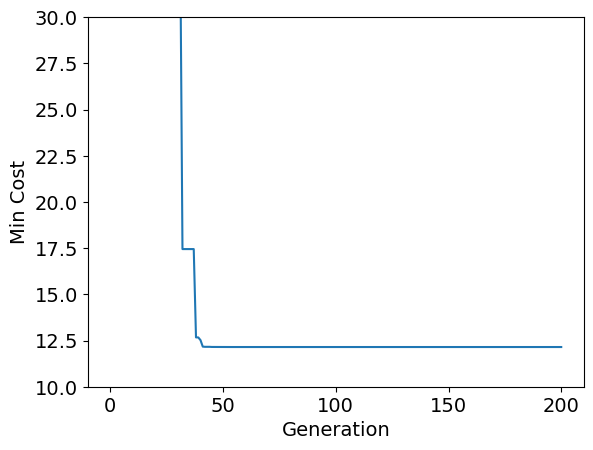

In [7]:
# Get data from logbook
gen = logbook.select("gen")
avgs = logbook.select("avg")
stds = logbook.select("std")
mins = logbook.select("min")

# Plotting
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
# Choosing min as mean is useless when we have such a large penalty for constaint violation
fig, ax1 = plt.subplots()
line1 = ax1.plot(gen, mins)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Min Cost")
ax1.set_ylim(10, 30)

# Statistical Analysis

In [8]:
def run_experiment(cxpb, mut_prob, num_runs=30):
    '''
    Runs multiple independent experiments to gather stochastic performance data, 
    '''
    results = []
    for _ in range(num_runs):
        pop = toolbox.population(n=POP_SIZE)
        temp_hof = tools.HallOfFame(1)
        algorithms.eaSimple(pop, toolbox, cxpb=cxpb, mutpb=mut_prob, ngen=NGEN, stats=None, halloffame=temp_hof, verbose=False)
        results.append(temp_hof[0].fitness.values[0])
    return results

# Run the test
low_mut = run_experiment(CXPB, 0.1)
high_mut = run_experiment(CXPB, 0.5)

# Calculate P-Value
u_stat, p_val = mannwhitneyu(low_mut, high_mut)

print(f"P-Value: {p_val}") 

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

# Configuration
NUM_RUNS = 30
MU_VAL = 1000
LAMBDA_VAL = 2000  # Higher for comma strategy to ensure valid offspring pool
CXPB_FIXED = 0.5
MUTPB_FIXED = 0.2

def run_comparison():
    strategies = {
        "eaSimple": [],
        "eaMuPlusLambda": [],
        "eaMuCommaLambda": []
    }

    print("Starting experiments... this may take a moment.")

    for i in range(NUM_RUNS):
        # 1. Test eaSimple
        pop_simple = toolbox.population(n=POP_SIZE)
        hof_simple = tools.HallOfFame(1)
        algorithms.eaSimple(pop_simple, toolbox, CXPB_FIXED, MUTPB_FIXED, NGEN, 
                            stats=None, halloffame=hof_simple, verbose=False)
        strategies["eaSimple"].append(hof_simple[0].fitness.values[0])

        # 2. Test eaMuPlusLambda
        pop_plus = toolbox.population(n=MU_VAL)
        hof_plus = tools.HallOfFame(1)
        algorithms.eaMuPlusLambda(pop_plus, toolbox, mu=MU_VAL, lambda_=LAMBDA_VAL, 
                                  cxpb=CXPB_FIXED, mutpb=MUTPB_FIXED, ngen=NGEN, 
                                  stats=None, halloffame=hof_plus, verbose=False)
        strategies["eaMuPlusLambda"].append(hof_plus[0].fitness.values[0])

        # 3. Test eaMuCommaLambda
        pop_comma = toolbox.population(n=MU_VAL)
        hof_comma = tools.HallOfFame(1)
        algorithms.eaMuCommaLambda(pop_comma, toolbox, mu=MU_VAL, lambda_=LAMBDA_VAL, 
                                   cxpb=CXPB_FIXED, mutpb=MUTPB_FIXED, ngen=NGEN, 
                                   stats=None, halloffame=hof_comma, verbose=False)
        strategies["eaMuCommaLambda"].append(hof_comma[0].fitness.values[0])
        print(i,end="",flush=True)

    return strategies

# Execute
results = run_comparison()

# Statistical Analysis (Rigour)
# Compare Simple vs Plus
u_stat, p_plus = mannwhitneyu(results["eaSimple"], results["eaMuPlusLambda"])
# Compare Plus vs Comma
u_stat, p_comma = mannwhitneyu(results["eaMuPlusLambda"], results["eaMuCommaLambda"])

print(f"P-value (Simple vs Plus): {p_plus:.4f}")
print(f"P-value (Plus vs Comma): {p_comma:.4f}")

# Visualization (Effective Presentation)
plt.figure(figsize=(12, 7))
plt.boxplot([results["eaSimple"], results["eaMuPlusLambda"], results["eaMuCommaLambda"]], 
            labels=['eaSimple', 'ea(μ+λ)', 'ea(μ,λ)'])
plt.title('Comparison of Evolutionary Strategies on Diet Cost Optimization')
plt.ylabel('Total Diet Cost (£)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('strategy_comparison.png')
plt.show()

Starting experiments... this may take a moment.
01

KeyboardInterrupt: 

: 

: 

: 